In [1]:
%pip install openneuro-py mne scikit-learn pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

mne.set_log_level('WARNING')
%matplotlib inline

DATA_DIR = Path('../data/raw')
PROC_DIR  = Path('../data/processed')
OUT_DIR   = Path('../outputs')
PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

SUBJECTS = ['001', '002', '003', '004', '005']
SESSIONS = list(range(1, 13))

GENRE_MAP = {
    1:'Deep House', 2:'Indie', 3:'Electronics', 4:'New Age',
    5:'Electronic Dance', 6:'Ambient', 7:'Hindustani Classical',
    8:'Indian Semi-Classical', 9:'Indian Folk', 10:'Soft Jazz',
    11:'Goth Rock', 12:'Progressive Instrumental Rock'
}

MUSIC_MARKERS = ['stm+', 'stim', 'music', 'song']
EPOCH_DURATION = 30.0  # seconds

print('Setup complete.')
print(f'Raw data : {DATA_DIR.resolve()}')
print(f'Processed: {PROC_DIR.resolve()}')

Setup complete.
Raw data : /workspaces/music-genre-eeg/data/raw
Processed: /workspaces/music-genre-eeg/data/processed


In [3]:
#Finding the timestamp where music starts.
def find_music_onset(raw):
    ann = raw.annotations
    for marker in MUSIC_MARKERS:
        mask = np.array([d.lower() == marker.lower() for d in ann.description])
        if mask.any():
            return ann.onset[mask][0], ann.description[mask][0]
    return raw.times[-1] / 2, 'fallback'

#Loading raw EEG for one subject/session.
def load_session(subject, session):
    
    eeg_dir  = DATA_DIR / f'sub-{subject}' / f'ses-{session:02d}' / 'eeg'
    set_file = next(eeg_dir.glob('*.set'))
    raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
    return raw

# Testing with sub-001, ses-01
raw = load_session('001', 1)
t_music, marker = find_music_onset(raw)
print(f'Session  : sub-001 ses-01 ({GENRE_MAP[1]})')
print(f'Marker   : "{marker}" at {t_music:.2f}s')
print(f'Channels : {len(raw.ch_names)}')
print(f'Duration : {raw.times[-1]:.1f}s')




Session  : sub-001 ses-01 (Deep House)
Marker   : "stim" at 7.41s
Channels : 129
Duration : 136.0s


/tmp/ipykernel_3610/4030207982.py:15: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_3610/4030207982.py:15: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_3610/4030207982.py:15: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)


In [4]:
# Bandpass Filter: removes slow drift (<1Hz) and high-freq muscle noise (>40Hz)
raw.load_data()

raw.filter(l_freq=1.0, h_freq=40.0, method='fir', verbose=False)
print('Bandpass filter applied: 1–40 Hz')

Bandpass filter applied: 1–40 Hz


In [5]:
# Notch Filter: Removes power line noise (50 Hz in India/Europe)
raw.notch_filter(freqs=50.0, verbose=False)
print('Notch filter applied: 50 Hz')

Notch filter applied: 50 Hz


In [6]:
## Bad Channel Detection and Interpolation

data     = raw.get_data()
chan_std  = data.std(axis=1)
threshold = np.median(chan_std) + 3.0 * chan_std.std()
bad_ch    = [raw.ch_names[i] for i, s in enumerate(chan_std) if s > threshold]

print(f'Bad channels detected: {len(bad_ch)}')
if bad_ch:
    print(f'  {bad_ch}')
    raw.info['bads'] = bad_ch
    raw.interpolate_bads(reset_bads=True, verbose=False)
    print('  Interpolated.')
else:
    print('  No bad channels.')

del data

Bad channels detected: 2
  ['E114', 'E119']
  Interpolated.


In [7]:
## Average Reference

raw.set_eeg_reference('average', projection=False, verbose=False)
print('Average reference applied.')

Average reference applied.


In [10]:
# Fit ICA on a high-pass filtered copy (ICA works better above 1Hz)

raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

ica = mne.preprocessing.ICA(
    n_components=40,
    method='fastica',
    random_state=42,
    max_iter=800,
    verbose=False
)
ica.fit(raw_ica, verbose=False)
del raw_ica
print(f'ICA fitted: {ica.n_components_} components')

ICA fitted: 40 components


In [11]:
# Auto-detect eye artifacts

try:
    eog_idx, _ = ica.find_bads_eog(raw, threshold=3.0, verbose=False)
    print(f'Eye artifact components: {eog_idx}')
except Exception:
    eog_idx = [0]  # remove first component as fallback
    print(f'Auto-detection failed — removing component 0 as fallback')

ica.exclude = eog_idx
ica.apply(raw, verbose=False)
print(f'ICA applied — {len(eog_idx)} component(s) removed.')

Auto-detection failed — removing component 0 as fallback
ICA applied — 1 component(s) removed.


In [ ]:
## Epoch Creation (30s from music start),crop to music segment only

t_end = min(t_music + EPOCH_DURATION, raw.times[-1])
epoch = raw.copy().crop(tmin=t_music, tmax=t_end)
del raw

print(f'Epoch shape: {epoch.get_data().shape}  (channels x timepoints)')
print(f'Duration   : {epoch.times[-1]:.1f}s')


Epoch shape: (129, 7501)  (channels x timepoints)
Duration   : 30.0s


In [13]:
# Save to data/processed/

out_file = PROC_DIR / 'sub-001_ses-01_clean.fif'
epoch.save(out_file, overwrite=True, verbose=False)
print(f'Saved: {out_file}')
del epoch

/tmp/ipykernel_3610/2119539810.py:4: RuntimeWarning: This filename (/workspaces/music-genre-eeg/notebooks/../data/processed/sub-001_ses-01_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  epoch.save(out_file, overwrite=True, verbose=False)


Saved: ../data/processed/sub-001_ses-01_clean.fif


In [14]:
## Run All Sessions

def preprocess_session(subject, session):
    """Full preprocessing pipeline for one session. Returns True if successful."""
    genre    = GENRE_MAP[session]
    out_file = PROC_DIR / f'sub-{subject}_ses-{session:02d}_clean.fif'

    if out_file.exists():
        print(f'  [SKIP] sub-{subject} ses-{session:02d} {genre}')
        return True

    eeg_dir = DATA_DIR / f'sub-{subject}' / f'ses-{session:02d}' / 'eeg'
    if not eeg_dir.exists() or not any(eeg_dir.glob('*.set')):
        print(f'  [MISS] sub-{subject} ses-{session:02d} — file not found')
        return False

    try:
        # Load
        set_file = next(eeg_dir.glob('*.set'))
        raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
        t_music, _ = find_music_onset(raw)

        # Filter
        raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
        raw.notch_filter(freqs=50.0, verbose=False)

        # Bad channels
        chan_std  = raw.get_data().std(axis=1)
        threshold = np.median(chan_std) + 3.0 * chan_std.std()
        bad_ch    = [raw.ch_names[i] for i, s in enumerate(chan_std) if s > threshold]
        if bad_ch:
            raw.info['bads'] = bad_ch
            raw.interpolate_bads(reset_bads=True, verbose=False)

        # Reference
        raw.set_eeg_reference('average', projection=False, verbose=False)

        # ICA
        raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
        ica = mne.preprocessing.ICA(n_components=40, method='fastica',
                                     random_state=42, max_iter=800, verbose=False)
        ica.fit(raw_ica, verbose=False)
        del raw_ica
        try:
            eog_idx, _ = ica.find_bads_eog(raw, threshold=3.0, verbose=False)
        except Exception:
            eog_idx = [0]
        ica.exclude = eog_idx
        ica.apply(raw, verbose=False)

        # Epoch & save
        t_end = min(t_music + EPOCH_DURATION, raw.times[-1])
        epoch = raw.copy().crop(tmin=t_music, tmax=t_end)
        epoch.save(out_file, overwrite=True, verbose=False)
        del raw, epoch

        print(f'  [OK]   sub-{subject} ses-{session:02d} {genre}')
        return True

    except Exception as e:
        print(f'  [ERR]  sub-{subject} ses-{session:02d}: {e}')
        return False

print('preprocess_session() ready.')

preprocess_session() ready.


In [15]:
# ICA is the slow step (~30s per session)

ok_count  = 0
err_count = 0

for sub in SUBJECTS:
    print(f'\n── sub-{sub} ──────────────────────────')
    for ses in SESSIONS:
        success = preprocess_session(sub, ses)
        if success:
            ok_count += 1
        else:
            err_count += 1

print(f'\nDone: {ok_count} OK, {err_count} errors')


── sub-001 ──────────────────────────
  [SKIP] sub-001 ses-01 Deep House


/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Omitted 110 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:54: RuntimeWarning: This filename (/workspaces/music-genre-eeg/notebooks/../data/processed/sub-001_ses-02_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  epoch.save(out_file, overwrite=True, verbose=False)


  [OK]   sub-001 ses-02 Indie


/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:54: RuntimeWarning: This filename (/workspaces/music-genre-eeg/notebooks/../data/processed/sub-001_ses-03_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.

  [OK]   sub-001 ses-03 Electronics


...

/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Omitted 110 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:54: RuntimeWarning: This filename (/workspaces/music-genre-eeg/notebooks/../data/processed/sub-005_ses-11_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  epoch.save(out_file, overwrite=True, verbose=False)


  [OK]   sub-005 ses-11 Goth Rock


/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Omitted 109 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2615301207.py:20: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)


  [OK]   sub-005 ses-12 Progressive Instrumental Rock

Done: 60 OK, 0 errors


/tmp/ipykernel_3610/2615301207.py:54: RuntimeWarning: This filename (/workspaces/music-genre-eeg/notebooks/../data/processed/sub-005_ses-12_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  epoch.save(out_file, overwrite=True, verbose=False)


In [16]:
# Count processed files
processed = list(PROC_DIR.glob('*.fif'))
print(f'Processed files: {len(processed)} / 60 expected')
print()
for sub in SUBJECTS:
    count = len(list(PROC_DIR.glob(f'sub-{sub}_*.fif')))
    print(f'  sub-{sub}: {count}/12')

Processed files: 60 / 60 expected

  sub-001: 12/12
  sub-002: 12/12
  sub-003: 12/12
  sub-004: 12/12
  sub-005: 12/12


/tmp/ipykernel_3610/2071736841.py:6: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw_orig = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2071736841.py:6: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw_orig = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2071736841.py:6: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_orig = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
/tmp/ipykernel_3610/2071736841.py:17: RuntimeWarning: This filename (../data/processed/sub-001_ses-01_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  clean = mne.io.read_r

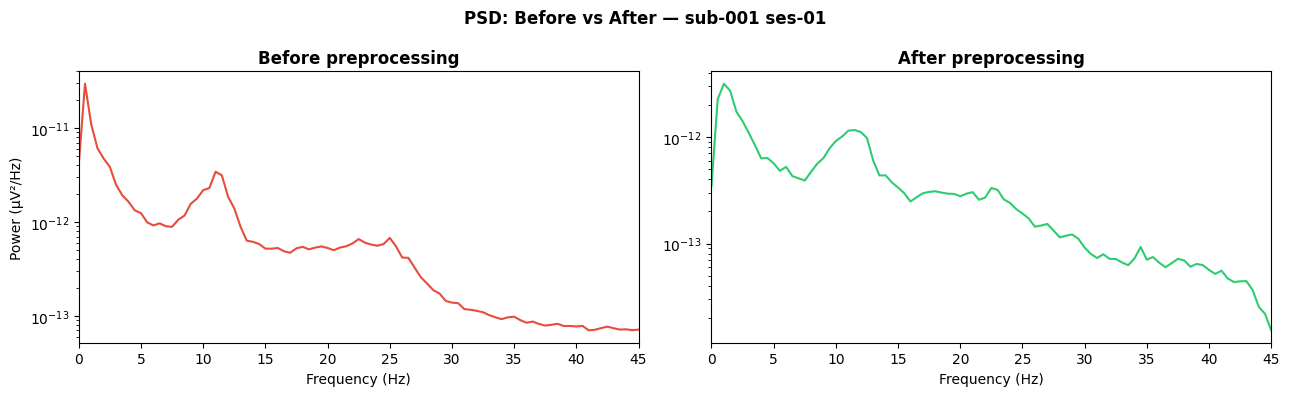

Saved: outputs/02_preproc_comparison.png


In [18]:
# Before vs after PSD comparison (sub-001, ses-01)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before: raw
set_file = next((DATA_DIR / 'sub-001' / 'ses-01').rglob('*.set'))
raw_orig = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
freqs, psd_raw = welch(raw_orig.get_data(), fs=raw_orig.info['sfreq'], nperseg=500)
axes[0].semilogy(freqs[freqs<=45], np.median(psd_raw, axis=0)[freqs<=45], color='#e74c3c')
axes[0].set_title('Before preprocessing', fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (μV²/Hz)')
del raw_orig, psd_raw

# After: cleaned
fif_file = PROC_DIR / 'sub-001_ses-01_clean.fif'
if fif_file.exists():
    clean = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    freqs, psd_clean = welch(clean.get_data(), fs=clean.info['sfreq'], nperseg=500)
    axes[1].semilogy(freqs[freqs<=45], np.median(psd_clean, axis=0)[freqs<=45], color='#2ecc71')
    axes[1].set_title('After preprocessing', fontweight='bold')
    axes[1].set_xlabel('Frequency (Hz)')
    del clean, psd_clean
else:
    axes[1].set_title('Not processed yet')

for ax in axes:
    ax.set_xlim(0, 45)
    ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50Hz')

OUTPUT_DIR = Path('../outputs') 
OUTPUT_DIR.mkdir(exist_ok=True)

plt.suptitle('PSD: Before vs After — sub-001 ses-01', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_preproc_comparison.png', dpi=120)
plt.show()
print('Saved: outputs/02_preproc_comparison.png')